# Portefeuille des élus du Congrès — spécification mathématique
**Reconstruction, classement, stratégie de copie et ajustement au marché**

Notebook calqué sur `NOTE_MATHS_PORTEFEUILLE_MEMBRE`. Réutilise le pipeline de données du `05`,
avec la **combinaison inter-membres corrigée** (poids qui dérivent, buy-and-hold) et
l'**ajustement par le marché** ($\beta$, $\alpha$, ratio d'appréciation).

Notations : $i$ = ticker, $t$ = jour de bourse, $P_i(t)$ = cours de clôture.

## 0. Données (nettoyage transactionnel fait en amont S1/S2)
Table canonique source-primaire + panel de prix `prices_v2` avec garde-fou anti-corruption Yahoo.

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices_v2")

In [2]:
# Table PROPRE canonique S1/S2 (source-primaire) -> noms alignés sur la mécanique du 05.
CLEAN = "/Users/lemairealice/Downloads/Jupiter/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
df = pd.read_csv(CLEAN, low_memory=False)
df = (df.drop(columns=["ticker"])
        .rename(columns={"member_name": "name", "ticker_yahoo": "ticker",
                         "direction": "op", "transaction_date": "traded",
                         "amount_midpoint": "size_usd"}))
n0 = len(df)
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].dt.year.between(2013, 2026)].reset_index(drop=True)
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]]
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")

134464 -> 134429 trades  |  372 membres  |  4618 tickers


In [3]:
df.head()   # aperçu : 1 ligne = 1 transaction déclarée

,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5
3,F000462,Lois Frankel,STJ,buy,2014-12-03,8000.5
4,F000462,Lois Frankel,MMM,sell,2014-12-10,8000.5


In [4]:
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché

In [5]:
# Télécharge les prix ABSENTS du cache (resumable ; cache complet => 0 => hors-ligne)
import yfinance as yf, time, logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)
os.makedirs(PRICES, exist_ok=True)
have0  = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
fail_f = os.path.join(PRICES, "failed_v2.csv")
failed = set(pd.read_csv(fail_f)["ticker"]) if os.path.exists(fail_f) else set()
todo   = [t for t in dict.fromkeys(df["ticker"]) if isinstance(t, str) and t not in have0 and t not in failed]
print(f"cache: {len(have0)} tickers | délistés/échecs connus sautés: {len(set(df['ticker']) & failed)} | à télécharger: {len(todo)}")
new_fail = []
for i in range(0, len(todo), 60):
    chunk = todo[i:i+60]
    try:
        data = yf.download(chunk, start="2012-01-01", end="2026-07-03", auto_adjust=True,
                           progress=False, threads=True, group_by="ticker")
    except Exception as e:
        print("  batch KO:", str(e)[:60]); data = None
    for t in chunk:
        s = None
        try:
            if data is not None and isinstance(data.columns, pd.MultiIndex):
                if t in data.columns.get_level_values(0):
                    s = data[t]["Close"].dropna()
            elif data is not None and "Close" in getattr(data, "columns", []):
                s = data["Close"].dropna()
        except Exception:
            s = None
        if s is None or len(s) < 20:
            new_fail.append(t)
        else:
            s.rename("close").to_csv(os.path.join(PRICES, t + ".csv"))
    time.sleep(0.4)
if new_fail:
    pd.DataFrame({"ticker": new_fail, "classe": "inattendu"}).to_csv(fail_f, mode="a", header=False, index=False)
print(f"téléchargés OK: {len(todo) - len(new_fail)} | nouveaux échecs: {len(new_fail)}")

cache: 3351 tickers | délistés/échecs connus sautés: 1268 | à télécharger: 0
téléchargés OK: 0 | nouveaux échecs: 0


In [6]:
# Charge les prix utiles, alignés sur le calendrier ; garde-fou anti-corruption Yahoo
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)
prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()
corrompus = [tk for tk in need if (len(prices[tk].dropna()) < 2
             or prices[tk].dropna().min() < 0.10
             or prices[tk].dropna().pct_change().abs().max() > 3.0)]   # <0,10$ ou saut >300%/j
for tk in corrompus:
    del prices[tk]
need = [tk for tk in need if tk not in set(corrompus)]
n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)} | sans prix : {len(missing)} | corrompus exclus : {len(corrompus)} | trades jetés : {n_drop}  => {len(df)} exploitables")

tickers avec prix : 3289 | sans prix : 1268 | corrompus exclus : 61 | trades jetés : 16400  => 118029 exploitables


## 1. Reconstruction du portefeuille d'un membre
- **Achat** $\to$ parts, au 1er jour coté $\ge$ date de transaction : $q = \dfrac{\text{montant}}{P_i(\tau)},\ \tau=\min\{t\ge \texttt{traded}\}$.
- **Vente** $\to$ retire des parts (short interdit) : $q^- = \min(\text{montant}/P_i,\ \text{parts détenues})$.
- **Détentions cumulées** : $n_i(t) = \sum_{\text{achats}\le t} q - \sum_{\text{ventes}\le t} q^-$.
- **Valeur** : $V(t) = \sum_i n_i(t)\,P_i(t)$.

In [7]:
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marché)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

def member_shares(g):
    # g = trades d'un membre  ->  N (parts détenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

In [8]:
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Barbara J. Comstock"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

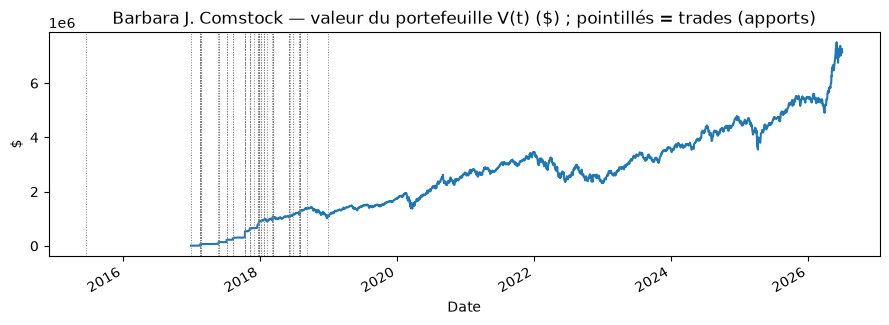

In [9]:
# Démo AUTO-SUFFISANTE : la VALEUR V(t) saute à chaque achat (apports + performance mélangés)
g_demo = df[df["bioguide_id"] == DEMO_BID]
Nm = member_shares(g_demo)
V = (Nm * pd.DataFrame({tk: prices[tk] for tk in Nm.columns})).sum(axis=1)
Va = V[Nm.sum(axis=1) > 0]
ax = Va.plot(figsize=(9, 3.5), color="tab:blue")
for d in g_demo["traded"]:
    ax.axvline(d, color="gray", ls=":", lw=0.7)
ax.set_title(f"{DEMO} — valeur du portefeuille V(t) ($) ; pointillés = trades (apports)")
ax.set_ylabel("$"); plt.tight_layout(); plt.show()

In [10]:
# Démo AUTO-SUFFISANTE : le tableau N des parts détenues n_i(t), une colonne par ticker
Nm = member_shares(df[df["bioguide_id"] == DEMO_BID])
actifs = Nm[Nm.sum(axis=1) > 0]
actifs.iloc[::max(1, len(actifs) // 8)].round(1)

,AAPL,ALNY,AMBA,AMZN,BA,CIBR,EMB,F,GRPN,HPE,...,VEA,VFH,VGT,VHT,VNQ,VO,VTV,VUG,VWO,XT
Date,,,,,,,,,,,,,,,,,,,,,
2016-12-28,297.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2018-03-07,7836.1,4.9,0.0,0.0,115.2,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,0.0,0.0,7449.1
2019-05-14,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2020-07-20,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2021-09-23,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2022-11-29,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2024-02-07,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2025-04-16,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1
2026-06-25,7999.4,4.9,0.0,1642.5,115.2,316.6,0.0,0.0,0.0,4386.3,...,0.0,0.0,1693.9,0.0,0.0,0.0,0.0,1324.9,0.0,1838.1


## 2. Rendement d'un membre (*time-weighted*)
On valorise les parts de la **veille** $\Rightarrow$ un apport n'est jamais un rendement :
$$r_P(t) = \frac{\sum_i n_i(t-1)P_i(t)}{\sum_i n_i(t-1)P_i(t-1)} - 1$$
- Jour sans position : $r_P(t)=0$ (système ouvert). Winsorisation $\pm50\,\%$/jour.
- $\mathrm{NAV}(t)=\prod_{s\le t}(1+r_P(s))$ : la **performance pure** (contrairement à $V(t)$ qui mélange les apports).

In [11]:
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Σ n_i(t-1) P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Σ n_i(t-1) P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    r = r.clip(-0.5, 0.5)                               # winsorisation ±50 %/jour
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]

def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr, vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

### Aperçu TOTAL : tous les membres d'un coup
On calcule la série de rendement de **chaque** membre une seule fois (réutilisée partout ensuite).
`member_shares`/`daily_return` sont cumulatifs $\Rightarrow$ tronquer à une date ne regarde jamais le futur.

In [12]:
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


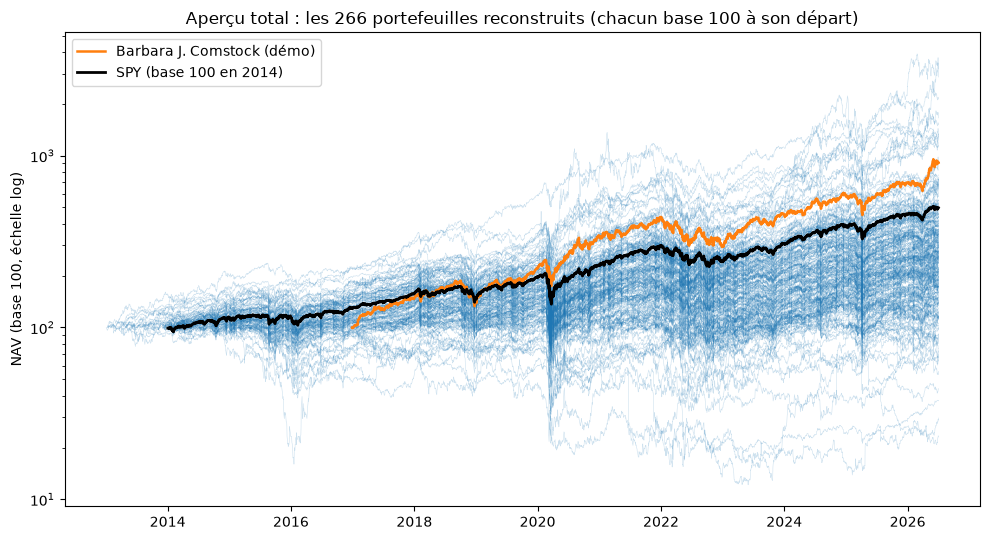

In [13]:
# VISUEL : la NAV de CHAQUE membre (base 100 à son premier jour actif), SPY en noir, démo en orange
plt.figure(figsize=(10, 5.5))
for bid, r in wf_ret.items():
    nav = 100 * (1 + r).cumprod()
    plt.plot(nav.index, nav.values, lw=0.4, alpha=0.22, color="tab:blue")
nav_demo = 100 * (1 + wf_ret[DEMO_BID]).cumprod()
plt.plot(nav_demo.index, nav_demo.values, lw=1.8, color="tab:orange", label=f"{DEMO} (démo)")
cal14 = cal[cal >= "2014-01-01"]
nav_spy = 100 * (1 + r_spy.reindex(cal14).fillna(0)).cumprod()
plt.plot(nav_spy.index, nav_spy.values, lw=2.0, color="k", label="SPY (base 100 en 2014)")
plt.yscale("log"); plt.ylabel("NAV (base 100, échelle log)")
plt.title(f"Aperçu total : les {len(wf_ret)} portefeuilles reconstruits (chacun base 100 à son départ)")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
# La distribution des stats sur TOUS les membres (le tableau de la population)
apercu = pd.DataFrame([{**stats(r), "n_days": len(r)} for r in wf_ret.values()])
apercu.describe().loc[["mean", "25%", "50%", "75%"]].round(3)

,cagr,vol,sharpe,maxdd,n_days
mean,0.146,0.254,0.683,-0.397,2078.812
25%,0.090,0.179,0.533,-0.460,1345.750
50%,0.128,0.216,0.706,-0.364,2270.000
75%,0.172,0.282,0.863,-0.310,3039.500


## 3. Qui est éligible ?
Un ratio de performance n'a de sens que sur assez de matière — un IR calculé sur 3 trades explose
(l'écart-type est minuscule) et ne veut rien dire. On ne garde donc que les membres avec :
$$n_{\text{trades}} \ge 10 \quad\text{et}\quad n_{\text{jours}} \ge 126\ (\sim 6\ \text{mois}).$$

In [15]:
# Éligibilité PURE (pas encore d'IR) : on part des séries de rendement déjà calculées (wf_ret)
MIN_TRADES, MIN_DAYS = 10, 126
tab = pd.DataFrame([dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=len(wf_traded[bid]), n_days=len(r))
                    for bid, r in wf_ret.items()])
elig = tab[(tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)].copy()
M = len(elig)
print(f"{len(tab)} membres avec historique -> {M} éligibles (>= {MIN_TRADES} trades ET >= {MIN_DAYS} jours)")

266 membres avec historique -> 223 éligibles (>= 10 trades ET >= 126 jours)


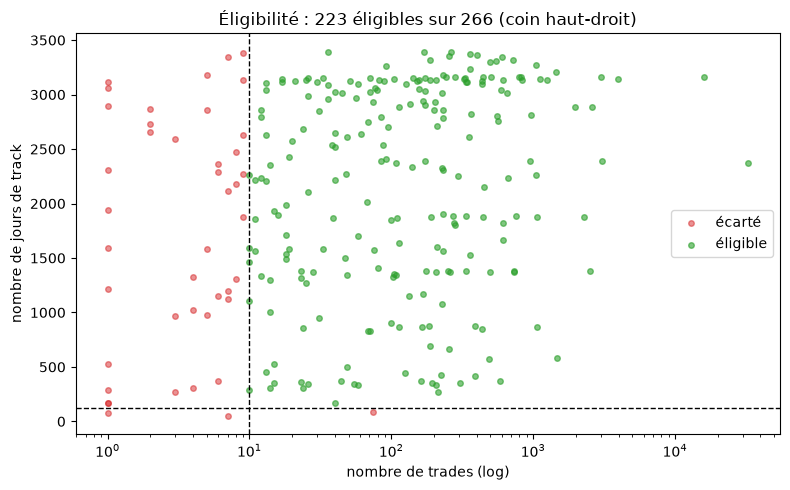

In [16]:
# VISUEL : qui passe la porte ? (n_trades en log x n_jours, la boîte d'éligibilité)
ok = (tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)
plt.figure(figsize=(8, 5))
plt.scatter(tab.n_trades[~ok], tab.n_days[~ok], s=16, alpha=0.5, color="tab:red", label="écarté")
plt.scatter(tab.n_trades[ok], tab.n_days[ok], s=16, alpha=0.6, color="tab:green", label="éligible")
plt.axvline(MIN_TRADES, color="k", ls="--", lw=1); plt.axhline(MIN_DAYS, color="k", ls="--", lw=1)
plt.xscale("log"); plt.xlabel("nombre de trades (log)"); plt.ylabel("nombre de jours de track")
plt.title(f"Éligibilité : {M} éligibles sur {len(tab)} (coin haut-droit)")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Qui bat le SPY — talent ou style ?
Deux critères, testés de la même façon (test $t$ unilatéral, seuil $1{,}645$) :

**Information Ratio** (suppose $\beta=1$) :
$$x(t)=r_P(t)-r_{SPY}(t),\quad \mathrm{IR}=\frac{\overline{x}}{\sigma(x)}\sqrt{252},\quad t=\mathrm{IR}\sqrt{n/252}$$

**Appraisal** (talent, marché retiré) — régression $r_P=\alpha+\beta\,r_{SPY}+\varepsilon$ :
$$\beta=\frac{\mathrm{Cov}(r_P,r_{SPY})}{\mathrm{Var}(r_{SPY})},\ \ \alpha=\overline{r_P}-\beta\,\overline{r_{SPY}},\ \ \text{appraisal}=\frac{\alpha}{\sigma(\varepsilon)}\sqrt{252},\ \ t_{\text{appr}}=\text{appraisal}\sqrt{n/252}$$

$\beta=1 \Rightarrow$ appraisal $=$ IR ; sinon l'IR mélange **exposition** (style) et **talent**.
⚠️ Sur $M=223$ tests **corrélés** (mêmes tickers, mêmes périodes), $\sim 11$ dépassements du seuil sont
attendus par pur hasard — et c'est une **borne basse** de l'incertitude (les tests ne sont pas indépendants).

In [17]:
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

def alpha_beta(r):
    """Régression r = alpha + beta*r_spy + eps -> beta, alpha annualisé, appraisal, t_appr."""
    d = pd.concat([r.rename("y"), r_spy.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return dict(beta=np.nan, alpha_ann=np.nan, appraisal=np.nan, t_appr=np.nan)
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)      # pente, ordonnée
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    appr = (alpha / se * np.sqrt(252)) if se > 0 else np.nan
    return dict(beta=beta, alpha_ann=(1 + alpha) ** 252 - 1, appraisal=appr,
                t_appr=appr * np.sqrt(len(d) / 252))

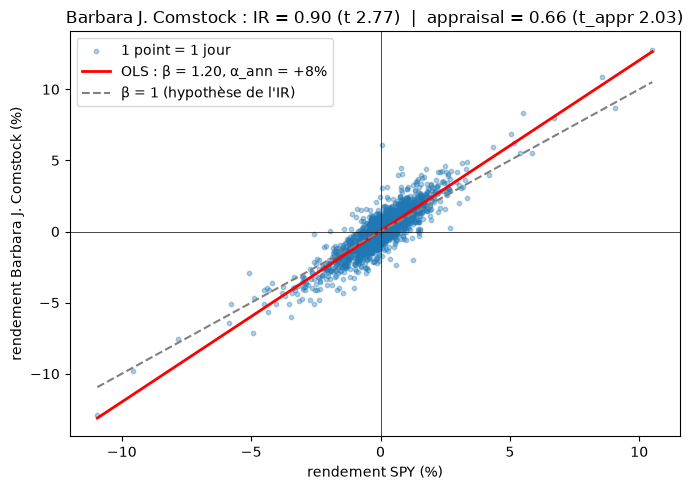

In [18]:
# Illustration AUTO-SUFFISANTE : la régression du membre démo décompose r_P en beta*SPY + alpha (+ résidu)
rm = daily_return(member_shares(df[df["bioguide_id"] == DEMO_BID]))
d = pd.concat([rm.rename("y"), r_spy.reindex(rm.index).rename("x")], axis=1).dropna()
beta, alpha = np.polyfit(d["x"], d["y"], 1)
ab = alpha_beta(rm)
ir = info_ratio(rm); t_ir = ir * np.sqrt(len(rm) / 252)
plt.figure(figsize=(7, 5))
plt.scatter(d["x"] * 100, d["y"] * 100, s=10, alpha=0.35, label="1 point = 1 jour")
xs = np.linspace(d["x"].min(), d["x"].max(), 50)
plt.plot(xs * 100, (alpha + beta * xs) * 100, color="red", lw=2,
         label=f"OLS : β = {beta:.2f}, α_ann = {ab['alpha_ann']:+.0%}")
plt.plot(xs * 100, xs * 100, color="gray", ls="--", label="β = 1 (hypothèse de l'IR)")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.xlabel("rendement SPY (%)"); plt.ylabel(f"rendement {DEMO} (%)")
plt.title(f"{DEMO} : IR = {ir:.2f} (t {t_ir:.2f})  |  appraisal = {ab['appraisal']:.2f} (t_appr {ab['t_appr']:.2f})")
plt.legend(); plt.tight_layout(); plt.show()

### 4.1 Classement par l'IR
On classe les éligibles par IR et on garde les significatifs ($t>1{,}645$).

In [19]:
elig["IR"] = [info_ratio(wf_ret[b]) for b in elig.bioguide_id]
elig["t"]  = elig.IR * np.sqrt(elig.n_days / 252)
sig = elig[elig.t > 1.645]
print(f"significatifs par l'IR (t > 1,645) : {len(sig)}   (~{0.05*M:.0f} attendus par pur hasard)")
COLS_IR = ["name", "n_trades", "n_days", "IR", "t"]
elig.sort_values("IR", ascending=False).head(8)[COLS_IR].round(3).reset_index(drop=True)

significatifs par l'IR (t > 1,645) : 20   (~11 attendus par pur hasard)


,name,n_trades,n_days,IR,t
0,John Fetterman,10,284,2.482,2.635
1,Ashley Moody,23,364,1.670,2.007
2,Morgan McGarvey,24,853,1.502,2.764
3,Lisa McClain,1479,580,1.264,1.917
4,Bruce Westerman,208,336,1.194,1.378
5,Kim Schrier,40,165,1.106,0.895
6,Daniel S Sullivan,100,904,0.999,1.892
7,Thomas Suozzi,662,2230,0.902,2.683


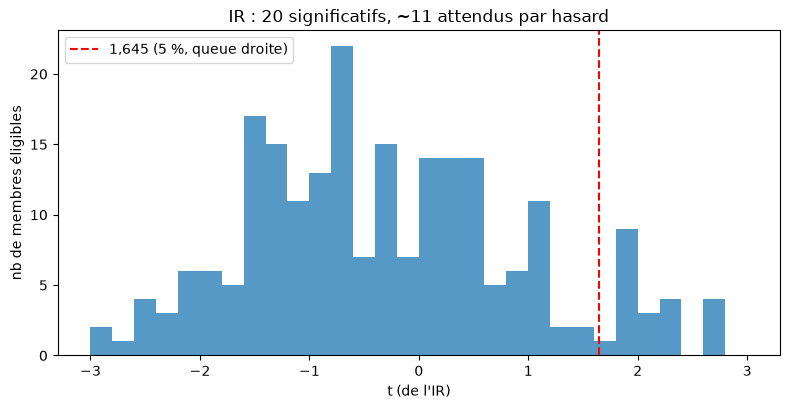

In [20]:
# FIGURE IR (style de référence, copié tel quel en 4.2) : distribution des t
BINS_T = np.linspace(-3, 3, 31)
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t.dropna(), bins=BINS_T, alpha=0.75, color="tab:blue")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'IR)"); plt.ylabel("nb de membres éligibles")
plt.title(f"IR : {len(sig)} significatifs, ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Classement par l'appraisal
Exactement la même chose, mais sur le **talent** (β retiré) : on classe par appraisal, on garde $t_{\text{appr}}>1{,}645$.

In [21]:
abdf = pd.DataFrame([alpha_beta(wf_ret[b]) for b in elig.bioguide_id], index=elig.index)
elig = pd.concat([elig, abdf], axis=1)          # ajoute beta / alpha_ann / appraisal / t_appr
sig_appr = elig[elig.t_appr > 1.645]
print(f"significatifs par l'appraisal (t_appr > 1,645) : {len(sig_appr)}   (~{0.05*M:.0f} attendus par pur hasard)")
COLS_APPR = ["name", "n_trades", "n_days", "appraisal", "t_appr"]
elig.sort_values("appraisal", ascending=False).head(8)[COLS_APPR].round(3).reset_index(drop=True)

significatifs par l'appraisal (t_appr > 1,645) : 12   (~11 attendus par pur hasard)


,name,n_trades,n_days,appraisal,t_appr
0,John Fetterman,10,284,2.242,2.380
1,Ashley Moody,23,364,1.365,1.640
2,Bruce Westerman,208,336,1.309,1.511
3,David J. Taylor,195,353,1.170,1.385
4,Morgan McGarvey,24,853,1.081,1.988
5,Kim Schrier,40,165,1.075,0.870
6,Julia Letlow,224,423,0.922,1.194
7,John James,257,661,0.905,1.467


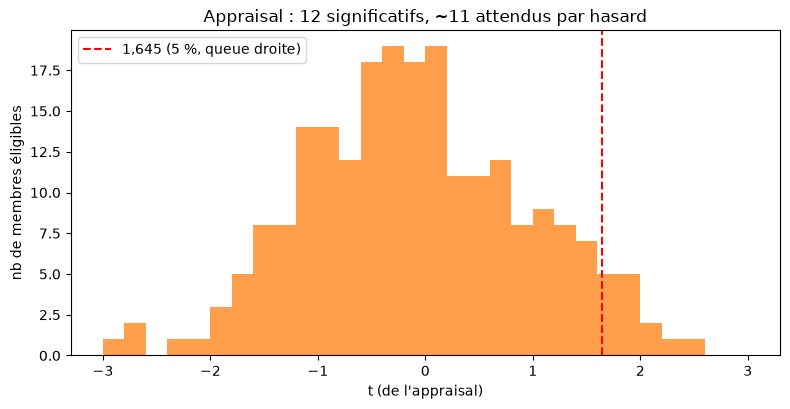

In [22]:
# FIGURE APPRAISAL (copie EXACTE du style de 4.1) : distribution des t_appr
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t_appr.dropna(), bins=BINS_T, alpha=0.75, color="tab:orange")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'appraisal)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Appraisal : {len(sig_appr)} significatifs, ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.3 Le lien entre les deux
L'IR et l'appraisal ne diffèrent que par le **β**. Chaque point ci-dessous : son IR (vertical) contre
son appraisal (horizontal), coloré par β.

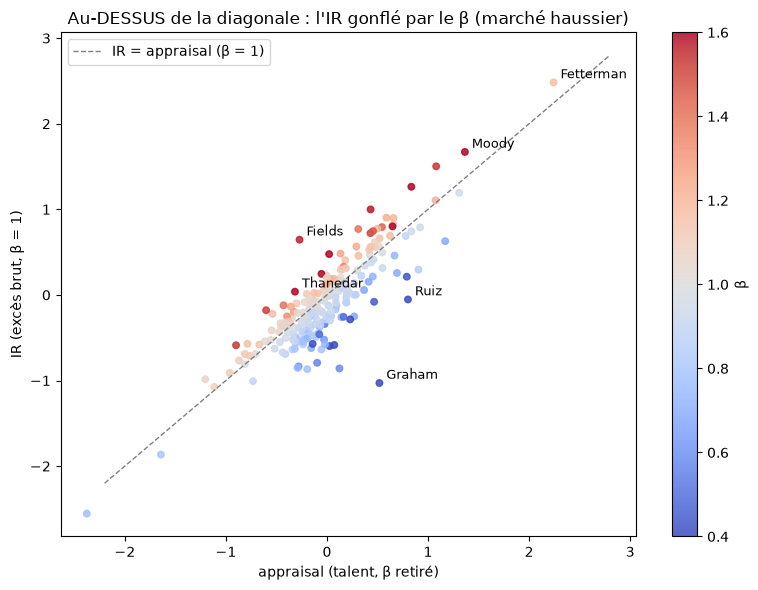

In [23]:
# FIGURE LIEN (le seul endroit où le beta paraît) : IR vs appraisal, couleur = beta
plt.figure(figsize=(8, 6))
sc = plt.scatter(elig.appraisal, elig.IR, c=elig.beta, cmap="coolwarm", vmin=0.4, vmax=1.6, s=22, alpha=0.85)
plt.colorbar(sc, label="β")
lim = [-2.2, 2.8]
plt.plot(lim, lim, color="gray", ls="--", lw=1, label="IR = appraisal (β = 1)")
for pat in ["Fetterman", "Moody", "Thanedar", "Fields", "Graham", "Ruiz"]:
    m = elig[elig.name.str.contains(pat, na=False)]
    if len(m):
        row = m.iloc[0]
        plt.annotate(pat, (row.appraisal, row.IR), fontsize=9, xytext=(5, 3), textcoords="offset points")
plt.xlabel("appraisal (talent, β retiré)"); plt.ylabel("IR (excès brut, β = 1)")
plt.title("Au-DESSUS de la diagonale : l'IR gonflé par le β (marché haussier)")
plt.legend(); plt.tight_layout(); plt.show()

**Lecture.**
- Le surnombre au niveau population **fond au niveau du hasard** : **20** significatifs par l'IR →
  **12** par l'appraisal ≈ ~11 attendus. La queue droite « significative » était surtout du **β**.
- Les portés par le marché **chutent** (Moody β 1,79 : t 2,01 → t_appr 1,64, sous le seuil ; Thanedar,
  Fields) ; des défensifs **montent** (Ruiz β 0,09 : t_appr 2,40 ; Graham).
- Ça n'exclut pas quelques vrais cas individuels — mais **les aurait-on trouvés à temps ?** → §5.

## 5. Choisir qui copier chaque année (walk-forward, point-in-time)
À chaque fin d'année $Y$, on classe les éligibles par un **critère** et on garde les significatifs :
$$\mathrm{classement}(Y)=\{\text{éligibles}\ \wedge\ t_{\text{crit}}>1{,}645\}\ \text{triés par le critère},$$
top-$K$ suivi en $Y{+}1$. Aucun regard vers le futur : $n_i(t)$ ne dépend que des trades $\le t$.
Même mécanique pour les **deux** critères (IR, appraisal) ; le choix du critère est étudié en §7.

In [24]:
def classement_a_fin(Y, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """Classement point-in-time au 31/12/Y. critere = "ir" (excès/SPY) ou "appraisal" (régression β)."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:yend]
        n_trades = int((wf_traded[bid] <= yend).sum())
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252)
            t = score * np.sqrt(n_days / 252)
        else:                                            # appraisal : régression sur le seul passé <= Y
            ab = alpha_beta(rr)
            score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=n_trades, n_days=n_days, score=score, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "score", "t"]
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

# Les DEUX caches co-définis ici (jamais de sélection avant que son cache existe)
clsmt    = {Y: classement_a_fin(Y, critere="ir")        for Y in range(2014, 2027)}
clsmt_ap = {Y: classement_a_fin(Y, critere="appraisal") for Y in range(2014, 2027)}

def select_topK(Y, K, critere="ir"):
    cache = clsmt if critere == "ir" else clsmt_ap
    c = cache[Y] if Y in cache else classement_a_fin(Y, critere=critere)
    return list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
print("classements point-in-time prêts (IR et appraisal, 2014-2026)")

classements point-in-time prêts (IR et appraisal, 2014-2026)


In [25]:
# TABLE SYMÉTRIQUE : nb de significatifs et tête du classement, par critère, à chaque coupe
def _tete(c): return c.name.iloc[0].split()[-1] if len(c) else "-"
resume = pd.DataFrame([
    dict(fenetre=f"2014-{Y}", n_sig_IR=len(clsmt[Y]), n_sig_appr=len(clsmt_ap[Y]),
         tete_IR=_tete(clsmt[Y]), tete_appr=_tete(clsmt_ap[Y]))
    for Y in range(2014, 2027)])
resume

,fenetre,n_sig_IR,n_sig_appr,tete_IR,tete_appr
0,2014-2014,1,3,Reed,Reed
1,2014-2015,4,4,McKinley,Chabot
2,2014-2016,2,4,Long,Brooks
3,2014-2017,4,4,Comstock,Khanna
4,2014-2018,5,7,Heck,Heck
5,2014-2019,8,11,Evans,Lee
6,2014-2020,19,21,Beyer,Beyer
7,2014-2021,13,10,Comstock,Heck
8,2014-2022,7,7,DelBene,Coble
9,2014-2023,12,12,Landsman,Sullivan


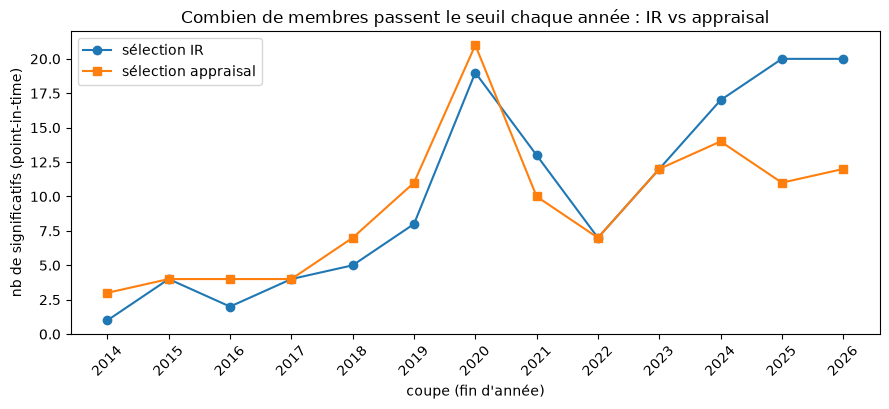

In [26]:
# FIGURE SYMÉTRIQUE : nb de significatifs par an, IR vs appraisal
annees = list(range(2014, 2027))
plt.figure(figsize=(9, 4.2))
plt.plot(annees, [len(clsmt[Y]) for Y in annees], marker="o", label="sélection IR")
plt.plot(annees, [len(clsmt_ap[Y]) for Y in annees], marker="s", label="sélection appraisal")
plt.xticks(annees, [str(y) for y in annees], rotation=45)
plt.ylabel("nb de significatifs (point-in-time)"); plt.xlabel("coupe (fin d'année)")
plt.title("Combien de membres passent le seuil chaque année : IR vs appraisal")
plt.legend(); plt.tight_layout(); plt.show()

**Lecture.**
- La tête du classement change presque chaque année → on copie un **panier top-$K$**, pas un individu.
- IR et appraisal retiennent un **nombre comparable** de membres à chaque coupe, mais **pas les mêmes** (l'appraisal écarte les β-portés) → les deux stratégies divergeront en §7.

## 6. La combinaison : buy-and-hold (commune aux deux critères)
« Copier et **tenir** » laisse les poids **dériver** avec la performance ; les figer reviendrait à
rebalancer chaque jour (faux) :
$$\mathrm{NAV}_k(t)=\prod_{s\le t}(1+r_{m_k}(s)),\quad N(t)=\sum_k w_k\,\mathrm{NAV}_k(t),\quad
r_{\text{strat}}(t)=\frac{N(t)}{N(t-1)}-1.$$

In [27]:
def run_strategy(K, mode, years=range(2015, 2026), combine="drift", critere="ir"):
    parts = []
    for Y in years:
        sel = select_topK(Y, K, critere=critere)
        if not sel:
            continue
        if mode == "equal":
            w = np.ones(len(sel)) / len(sel)
        else:                                             # "score" = poids proportionnels au score du critère
            sc = np.array([s for s, _ in sel])
            w = sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)
        idx = cal[cal.year == (Y + 1)]
        if len(idx) == 0:
            continue
        R = pd.DataFrame({bid: wf_ret[bid].reindex(idx).fillna(0.0) for _, bid in sel})
        if combine == "fixed":                       # ANCIEN : poids figés = rebalancement quotidien
            parts.append((R * w).sum(axis=1))
        else:                                         # DRIFT : poids qui dérivent (buy-and-hold)
            navk = (1 + R).cumprod()
            navc = (navk * w).sum(axis=1)
            ry = navc / navc.shift(1) - 1
            ry.iloc[0] = navc.iloc[0] - 1
            parts.append(ry)
    return pd.concat(parts).sort_index()

def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

# les 4 séries de sélection IR (calculées une fois)
r_fix_eq = run_strategy(4, "equal", combine="fixed", critere="ir")
r_dr_eq  = run_strategy(4, "equal", combine="drift", critere="ir")
r_fix_ir = run_strategy(4, "score", combine="fixed", critere="ir")
r_dr_ir  = run_strategy(4, "score", combine="drift", critere="ir")
print("séries stratégie prêtes")

séries stratégie prêtes


In [28]:
# La combinaison figée SURESTIME : top-4 sélection IR, figé vs dérive
pd.DataFrame({
    "top-4 sél IR (1/K) — figé":   eval_yearly(r_fix_eq),
    "top-4 sél IR (1/K) — dérive": eval_yearly(r_dr_eq),
}).T[["exces_moyen", "t", "gagnantes"]].round(3)

,exces_moyen,t,gagnantes
top-4 sél IR (1/K) — figé,0.036491,1.141628,7/11
top-4 sél IR (1/K) — dérive,0.031021,0.943191,7/11


**Lecture.** Les poids figés **surestiment** (rebalancement fantôme) : le $t$ passe de $1{,}14$
(figé) à $0{,}94$ (dérive). On garde la dérive partout.

## 7. Top-4 : sélection IR vs sélection appraisal
On copie chaque année les 4 meilleurs — une fois classés par **IR**, une fois par **appraisal** —
et on compare (combinaison dérive, 2016-2026).

In [29]:
# séries de sélection APPRAISAL (miroir des séries sél-IR)
r_ap_eq = run_strategy(4, "equal", combine="drift", critere="appraisal")
r_ap_w  = run_strategy(4, "score", combine="drift", critere="appraisal")

# LA comparaison : 2 colonnes symétriques (IR vs appraisal), métriques en lignes, tout formaté
def _col(r):
    e = eval_yearly(r); a = alpha_beta(r)
    fr = lambda x, f: format(x, f).replace("-", "−").replace(".", ",")
    return {"excès/an":         fr(e["exces_moyen"], "+.1%"),
            "t":                 fr(e["t"], ".2f"),
            "années gagnantes":  e["gagnantes"],
            "β":                 fr(a["beta"], ".2f"),
            "α annualisé":       fr(a["alpha_ann"], "+.1%"),
            "t (appraisal)":     fr(a["t_appr"], ".2f")}
pd.DataFrame({"sélection IR": _col(r_dr_eq), "sélection appraisal": _col(r_ap_eq)})

,sélection IR,sélection appraisal
excès/an,"+3,1%","−2,5%"
t,"0,94","−1,24"
années gagnantes,7/11,3/11
β,"1,20","1,01"
α annualisé,"−0,4%","−2,3%"
t (appraisal),"−0,13","−0,75"


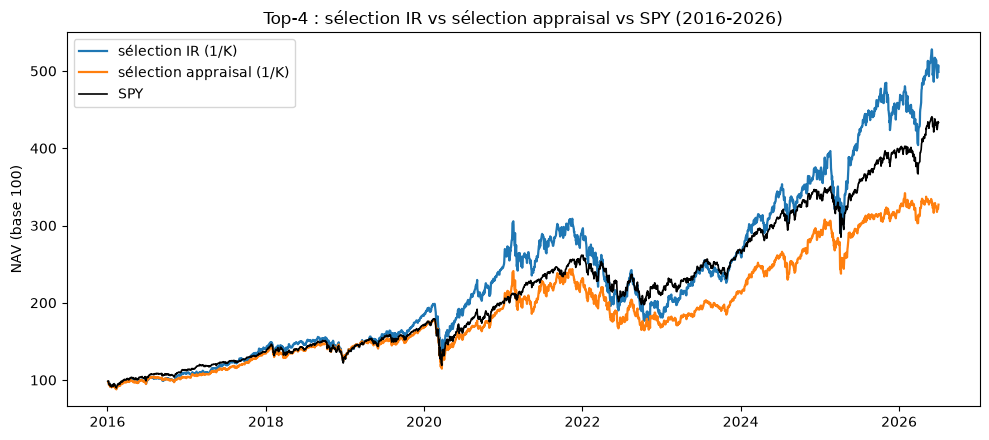

In [30]:
# FIGURE : NAV sélection IR vs sélection appraisal vs SPY (base 100)
nav_ir = 100 * (1 + r_dr_eq).cumprod()
nav_ap = 100 * (1 + r_ap_eq).cumprod()
idx = nav_ir.index.union(nav_ap.index)
nav_sp = 100 * (1 + r_spy.reindex(idx).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_ir, label="sélection IR (1/K)", lw=1.6)
plt.plot(nav_ap, label="sélection appraisal (1/K)", lw=1.6)
plt.plot(nav_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)"); plt.title("Top-4 : sélection IR vs sélection appraisal vs SPY (2016-2026)")
plt.legend(); plt.tight_layout(); plt.show()

**Lecture.**
- **Aucune** des deux sélections n'a d'$\alpha$ ($t_{\text{appr}}\le 0$).
- Sélection **IR** : $+3{,}1\,\%$/an, mais $\beta\approx1{,}20$ = simple **tilt de style** ($\beta$ instable sur les historiques courts, d'où le choix de l'IR pour la sélection réelle).
- Sélection **appraisal** : $\beta\approx1{,}0$ (le style est neutralisé) **mais** $-2{,}5\,\%$/an → l'appraisal passé ne prédit pas l'$\alpha$ futur (pas de persistance du talent).
- Pondérer $\propto$ score au lieu de $1/K$ ne change rien (IR $t=0{,}90$, appraisal $t=-0{,}76$).

## 8. Combien copier ? (le choix de $K$)
- **Balayage statique** $K\in[4,20]$ (diagnostic in-sample) ; choisir le meilleur $K$ a posteriori serait du regard futur.
- **Walk-forward** : à fin $Y$, $K^*(Y)=\arg\max_K \mathrm{IR}_{\text{quotidien}}\big(\text{strat-}K\big|_{\le Y}\big)$ ; $K=4$ par défaut sans historique. Testé pour les **deux** critères de sélection.

In [31]:
# Précalcul des séries-K, PAR CRITÈRE DE SÉLECTION (poids 1/K fixé)
KS = list(range(4, 21))
R_K_ir = {K: run_strategy(K, "equal", combine="drift", critere="ir")        for K in KS}
R_K_ap = {K: run_strategy(K, "equal", combine="drift", critere="appraisal") for K in KS}
print(f"{2*len(KS)} séries-K prêtes (sélection IR et appraisal)")

34 séries-K prêtes (sélection IR et appraisal)


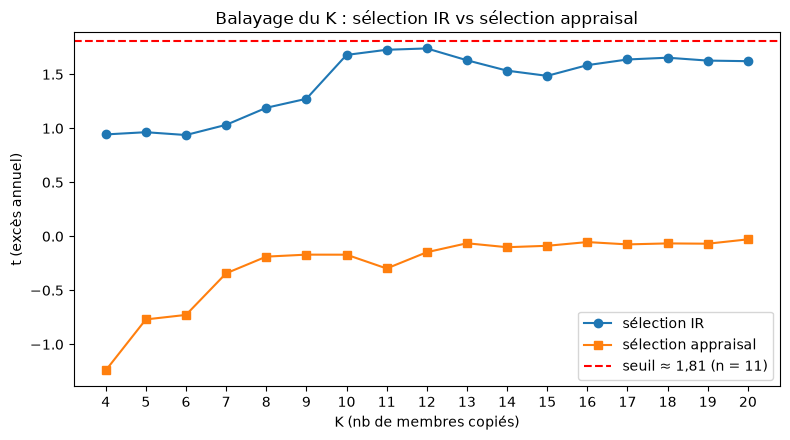

In [32]:
# FIGURE t-vs-K : 2 courbes = sélection IR vs sélection appraisal (corrige la confusion poids/critère)
t_ir = [eval_yearly(R_K_ir[K])["t"] for K in KS]
t_ap = [eval_yearly(R_K_ap[K])["t"] for K in KS]
plt.figure(figsize=(8, 4.5))
plt.plot(KS, t_ir, marker="o", label="sélection IR")
plt.plot(KS, t_ap, marker="s", label="sélection appraisal")
plt.axhline(1.81, color="red", ls="--", label="seuil ≈ 1,81 (n = 11)")
plt.xlabel("K (nb de membres copiés)"); plt.ylabel("t (excès annuel)"); plt.xticks(KS)
plt.title("Balayage du K : sélection IR vs sélection appraisal")
plt.legend(); plt.tight_layout(); plt.show()

In [33]:
# K walk-forward + TABLE symétrique : K=4 fixe vs K-wf, pour chaque critère
def ir_quotidien(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else -np.inf

def k_walk_forward(RbyK):
    parts = []
    for Y in range(2015, 2026):
        if Y == 2015:
            k_star = 4                                    # aucun historique
        else:
            fin = pd.Timestamp(f"{Y}-12-31")
            sc = {K: ir_quotidien(RbyK[K].loc[:fin]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        ry = RbyK[k_star][RbyK[k_star].index.year == Y + 1]
        parts.append(ry)
    return pd.concat(parts).sort_index()

r_wfK_eq = k_walk_forward(R_K_ir)     # sélection IR
r_wfK_ap = k_walk_forward(R_K_ap)     # sélection appraisal
pd.DataFrame({
    "K=4 fixe (sél IR)":              _ligne(r_dr_eq),
    "K walk-forward (sél IR)":        _ligne(r_wfK_eq),
    "K=4 fixe (sél appraisal)":       _ligne(r_ap_eq),
    "K walk-forward (sél appraisal)": _ligne(r_wfK_ap),
}).T.round(3)

,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR),0.031021,0.943191,7/11,1.198154,-0.004367,-0.127805
K walk-forward (sél IR),0.040673,1.58412,7/11,1.16856,0.011487,0.445576
K=4 fixe (sél appraisal),-0.025215,-1.24163,3/11,1.009716,-0.022867,-0.754999
K walk-forward (sél appraisal),-0.009955,-0.541885,5/11,0.973503,-0.005792,-0.289887


**Lecture.**
- Côté **IR**, laisser $K$ se choisir relève le $t$ ($+4{,}1\,\%$/an, $t=1{,}58$) mais reste **sous** $1{,}81$.
- Côté **appraisal**, aucun $K$ ne redresse l'excès (négatif). Verdict inchangé : pas d'alpha.

In [34]:
print("=" * 64)
print("RÉSUMÉ — copy-trading du Congrès vs SPY (combinaison corrigée)")
print("=" * 64)
print(f"Membres avec historique         : {len(wf_ret)}")
print(f"Éligibles (>=10 trades, >=126j) : {len(elig)}")
print(f"Significatifs IR / appraisal    : {len(sig)} / {len(sig_appr)}  (~{0.05*M:.0f} attendus par hasard, borne basse : tests corrélés)")
for nom, r in [("top-4 sél IR   [1/K]", r_dr_eq), ("K-wf  sél IR   [1/K]", r_wfK_eq),
               ("top-4 sél APPR [1/K]", r_ap_eq), ("K-wf  sél APPR [1/K]", r_wfK_ap)]:
    m = eval_yearly(r); a = alpha_beta(r)
    print(f"{nom} : excès {m['exces_moyen']*100:+.1f}%/an | t {m['t']:.2f} | gagnantes {m['gagnantes']} "
          f"| β {a['beta']:.2f} | α {a['alpha_ann']:+.1%} (t_appr {a['t_appr']:.2f})")
print("=" * 64)
print("Verdict : β retiré -> α ≈ 0 -> l'excès était du β de style, pas du talent.")

RÉSUMÉ — copy-trading du Congrès vs SPY (combinaison corrigée)
Membres avec historique         : 266
Éligibles (>=10 trades, >=126j) : 223
Significatifs IR / appraisal    : 20 / 12  (~11 attendus par hasard, borne basse : tests corrélés)
top-4 sél IR   [1/K] : excès +3.1%/an | t 0.94 | gagnantes 7/11 | β 1.20 | α -0.4% (t_appr -0.13)
K-wf  sél IR   [1/K] : excès +4.1%/an | t 1.58 | gagnantes 7/11 | β 1.17 | α +1.1% (t_appr 0.45)
top-4 sél APPR [1/K] : excès -2.5%/an | t -1.24 | gagnantes 3/11 | β 1.01 | α -2.3% (t_appr -0.75)
K-wf  sél APPR [1/K] : excès -1.0%/an | t -0.54 | gagnantes 5/11 | β 0.97 | α -0.6% (t_appr -0.29)
Verdict : β retiré -> α ≈ 0 -> l'excès était du β de style, pas du talent.
